Step 1: Import Libraries

In [26]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import image_dataset_from_directory
import matplotlib.pyplot as plt


Step 2: Dataset Path

In [27]:
dataset_path = "Garbage classification/Garbage classification"

Step 3: Load Dataset

In [28]:

train = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128,128),
    batch_size=32
)

val = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128,128),
    batch_size=32
)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.


Step 4: Display Class Names

In [29]:
class_names = train.class_names

print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


Step 5: Visualize Images

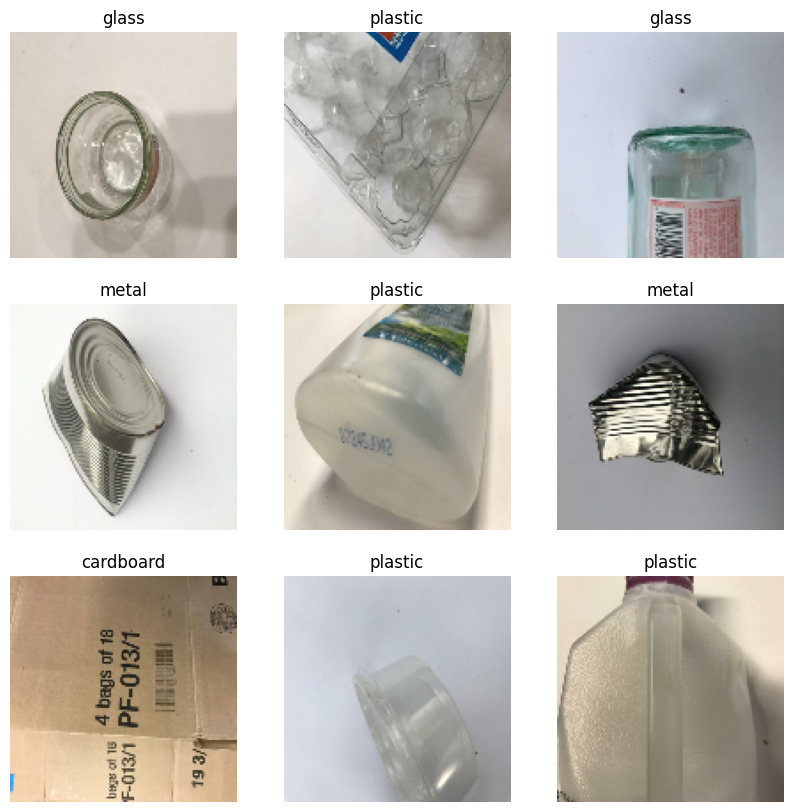

In [30]:
plt.figure(figsize=(10,10))

for images, labels in train.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

Step 6: Improve Performance

In [31]:
AUTOTUNE = tf.data.AUTOTUNE

train = train.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

val = val.cache().prefetch(buffer_size=AUTOTUNE)

Step 7: Normalize Images

In [32]:

normalization_layer = layers.Rescaling(1./255)

Step 8: Build CNN Model

In [33]:
model = models.Sequential([

    normalization_layer,

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(len(class_names),activation='softmax')

])

Step 9: Compile Model

In [35]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Step 10: Model Summary

In [36]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Step 11: Train Model

In [37]:
history = model.fit(
    train,
    validation_data=val,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 75s 885ms/step - accuracy: 0.2431 - loss: 1.7505 - val_accuracy: 0.4297 - val_loss: 1.4506
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 50s 778ms/step - accuracy: 0.4498 - loss: 1.3849 - val_accuracy: 0.4396 - val_loss: 1.3860
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 49s 760ms/step - accuracy: 0.4695 - loss: 1.3016 - val_accuracy: 0.4515 - val_loss: 1.3330
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 49s 769ms/step - accuracy: 0.5334 - loss: 1.2248 - val_accuracy: 0.5683 - val_loss: 1.1104
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 40s 620ms/step - accuracy: 0.5850 - loss: 1.0935 - val_accuracy: 0.5842 - val_loss: 1.1214
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 36s 569ms/step - accuracy: 0.6124 - loss: 1.0207 - val_accuracy: 0.6000 - val_loss: 1.0549
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 35s 551ms/step - accuracy: 0.6390 - loss: 0.9986 - val_accuracy: 0.5584 - val_loss: 1.1398
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 502ms/step - accuracy: 0.6447 - loss: 0.9387 - val_accu

step 12 -> Accuracy Graph


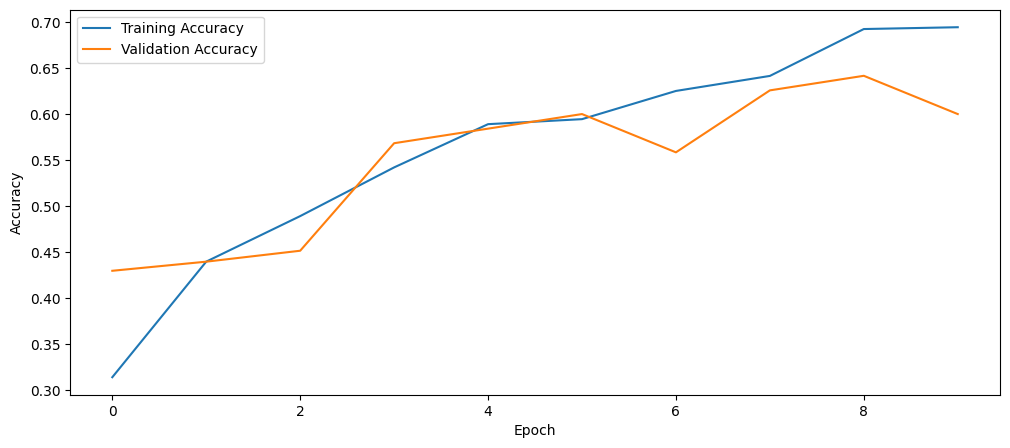

In [40]:
plt.figure(figsize=(12,5))

plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

Step 13: Plot Loss

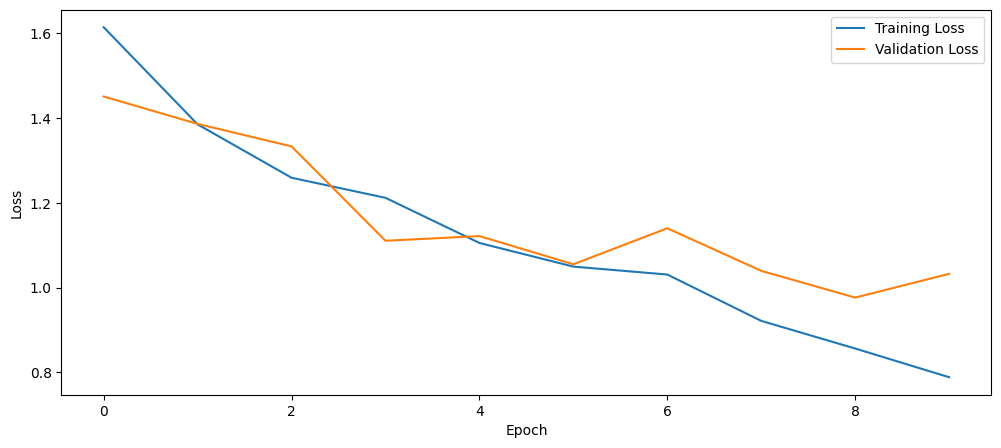

In [41]:
plt.figure(figsize=(12,5))

plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

Step 14: Evaluate Model

In [42]:
loss, accuracy = model.evaluate(val)

print("Validation Accuracy :", accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 227ms/step - accuracy: 0.6017 - loss: 1.0464
Validation Accuracy : 0.6000000238418579


Step 15: Save Model

In [43]:
model.save("garbage_classifier.keras")

Step 16: Predict on a New Image

In [45]:
from tensorflow.keras.preprocessing import image
import numpy as np

In [50]:
img = image.load_img(
    r"C:\files\AU jupyter\DL]\cardboard.png",
    target_size=(128,128)
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array,axis=0)
prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

print("Predicted Class :", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Class : cardboard
